In [1]:
import json
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.linear_model import Ridge
from prophet import Prophet
import optuna
import shap
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns
import warnings, logging
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
logging.getLogger('prophet').setLevel(logging.WARNING)

In [2]:
from pathlib import Path
DATA_DIR = Path('../data/processed/pre_processed/')
OUT_DIR  = Path('../output/')
OUT_DIR.mkdir(parents=True, exist_ok=True)

### 1. Load dữ liệu

In [3]:
print("Đang nạp dữ liệu từ thư mục Features...")

# 1. Nạp lại DataFrame chứa features
feat = pd.read_parquet('../data/features/train_feat.parquet')
test_df = pd.read_parquet('../data/features/test_feat.parquet')

# 2. Nạp lại Target
y_rev = np.load('../data/features/y_rev.npy')
y_cog = np.load('../data/features/y_cog.npy')

# 3. Khôi phục lại các biến phụ trợ 
NON_FEATURES = {'Date', 'Revenue', 'COGS'}
cols = [c for c in feat.columns if c not in NON_FEATURES]

X_tr = feat[cols].values.astype(float)
X_te = test_df[cols].values.astype(float)
years = feat['Date'].dt.year.values

# Tính lại w_full (Trọng số thời gian)
dates_sr = feat['Date']
days_from_end = (dates_sr.max() - dates_sr).dt.days
w_full = np.exp(-days_from_end / 1000.0)

print(f'Training shape: {X_tr.shape}, Test shape: {X_te.shape}, Số lượng Features: {len(cols)}')

Đang nạp dữ liệu từ thư mục Features...
Training shape: (3833, 81), Test shape: (548, 81), Số lượng Features: 81


### 5. Sample weight (high_era)
Ưu tiên 2014-2018 vì đây là vùng có seasonality rõ nhất.


In [4]:
w_full = np.full(len(years), 0.01)
w_full[(years>=2014) & (years<=2018)] = 1.0
print(f'Days with w=1.0: {(w_full==1.0).sum()}, w=0.01: {(w_full==0.01).sum()}')

Days with w=1.0: 1826, w=0.01: 2007


### 6. M1 — Ridge Regression

In [5]:
def train_ridge(X_train, y_train, alpha=3.0):
    mu = X_train.mean(axis=0)
    sigma = X_train.std(axis=0).replace(0, 1)
    Xs = (X_train - mu) / sigma
    m = Ridge(alpha=alpha, random_state=42)
    m.fit(Xs, y_train)
    return m, (mu, sigma)

def predict_ridge(model, X_test, stats):
    mu, sigma = stats
    return model.predict((X_test - mu) / sigma)

ridge_rev, st_r = train_ridge(pd.DataFrame(X_tr, columns=cols), y_rev)
ridge_cog, st_c = train_ridge(pd.DataFrame(X_tr, columns=cols), y_cog)

p_rd_rev = np.exp(predict_ridge(ridge_rev, pd.DataFrame(X_te, columns=cols), st_r))
p_rd_cog = np.exp(predict_ridge(ridge_cog, pd.DataFrame(X_te, columns=cols), st_c))

print(f'Ridge Revenue: {p_rd_rev.mean():,.0f}')
print(f'Ridge COGS:    {p_rd_cog.mean():,.0f}')

Ridge Revenue: 3,030,994
Ridge COGS:    2,721,462


In [6]:
# --- Xuất Submission cho Ridge Regression ---
sub_ridge = pd.DataFrame({
    'Date':    test_df['Date'].dt.strftime('%Y-%m-%d').values,
    'Revenue': p_rd_rev,
    'COGS':    p_rd_cog
})
path_ridge = OUT_DIR / 'submission_base_ridge.csv'
sub_ridge.to_csv(path_ridge, index=False)
print(f'✅ Đã lưu submission Ridge tại: {path_ridge}')

✅ Đã lưu submission Ridge tại: ..\output\submission_base_ridge.csv


### 7. M2 — LightGBM (high_era)
Two-stage: early stopping → retrain với best_iteration.

#### 7.1. Optuna

- Dưới đây là code dùng Optuna để tìm tham số tối ưu nhất của LightGBM (Đạt điểm cao nhất khi thực nghiệm trên Public Leaderboard).
- Vì Optuna chạy random để tìm điểm tối ưu trong không gian nên chỉ dùng để thử nghiệm, sau khi tìm được tham số sẽ tiến hành xuất ra và sử dụng tham số cố định để đảm bảo tính tái lập.

In [7]:
# def optimize_lgb(X, y, w, target_name, n_trials=30):
#     def objective(trial):
#         param = {
#             # --- 1. LÕI LIGHTGBM DÙNG HUBER LOSS ---
#             'objective': 'huber', 
#             'alpha': trial.suggest_float('alpha', 1.0, 5.0), # Điểm bẻ lái giữa L1 và L2
            
#             'metric': 'mae', # Dùng MAE để Early Stopping hoạt động ổn định
#             'verbosity': -1,
#             'seed': 42,
#             'deterministic': True, # Đã sửa lỗi cú pháp (True viết hoa và thêm dấu phẩy)
            
#             'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
#             'num_leaves': trial.suggest_int('num_leaves', 31, 256),
#             'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 100),
#             'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
#             'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
#             'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
#             'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
#             'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
#         }

#         # Chia tập Validation 
#         intern = pd.Timestamp('2022-07-04')
#         fit_idx = (feat['Date'] <= intern).values
#         ins_idx = (feat['Date'] >  intern).values

#         # Train mô hình trên tập fit, early stopping trên tập ins
#         bk = lgb.train(
#             param,
#             lgb.Dataset(X[fit_idx], y[fit_idx], weight=w[fit_idx]),
#             num_boost_round=3000,
#             valid_sets=[lgb.Dataset(X[ins_idx], y[ins_idx])],
#             callbacks=[lgb.early_stopping(100, verbose=False)]
#         )

#         # Tính toán trên thang đo thực (VNĐ)
#         preds = np.exp(bk.predict(X[ins_idx]))
#         actuals = np.exp(y[ins_idx])
        
#         # --- 2. TÍNH TOÁN 3 METRICS ---
#         mae_score = mean_absolute_error(actuals, preds)
#         rmse_score = np.sqrt(mean_squared_error(actuals, preds))
#         r2 = r2_score(actuals, preds)
        
#         # --- 3. HÀM PHẠT KẾT HỢP CHO OPTUNA ---
#         # Bắt Optuna phải nhượng bộ giữa MAE và RMSE (từ đó đẩy R2 lên cao nhất)
#         combined_score = (0.5 * mae_score) + (0.5 * rmse_score)
        
#         # Lưu r2 vào attributes của trial để tiện theo dõi nếu cần
#         trial.set_user_attr("MAE", mae_score)
#         trial.set_user_attr("RMSE", rmse_score)
#         trial.set_user_attr("R2", r2)
        
#         return combined_score
    
#     print(f"Bắt đầu tối ưu Optuna cho {target_name}...")
#     study = optuna.create_study(direction='minimize')
#     study.optimize(objective, n_trials=n_trials)
    
#     # Lấy param tốt nhất và gắn thêm các cấu hình cố định
#     best_params = study.best_params
    
#     # Cập nhật objective tương ứng cho best_params
#     best_params.update({
#         'objective': 'huber', 
#         'metric': 'mae', 
#         'verbosity': -1, 
#         'seed': 42,
#         'deterministic': True
#     })
    
#     # In ra các chỉ số tốt nhất của trial
#     best_trial = study.best_trial
#     print(f"--- KẾT QUẢ TỐT NHẤT CHO {target_name} ---")
#     print(f"Combined Score: {best_trial.value:,.0f}")
#     print(f"  MAE : {best_trial.user_attrs['MAE']:,.0f}")
#     print(f"  RMSE: {best_trial.user_attrs['RMSE']:,.0f}")
#     print(f"  R2  : {best_trial.user_attrs['R2']:.4f}")
    
#     return best_params

# # THỰC THI OPTUNA
# best_params_rev = optimize_lgb(X_tr, y_rev, w_full, "Revenue", n_trials=100)
# best_params_cog = optimize_lgb(X_tr, y_cog, w_full, "COGS", n_trials=100)

**Tham số tối ưu** - Sử dụng sau khi đã tìm được

In [8]:
best_params_rev = {
        "alpha": 4.651206740228129,
        "learning_rate": 0.012649306946952866,
        "num_leaves": 106,
        "min_data_in_leaf": 20,
        "feature_fraction": 0.8929877808289013,
        "bagging_fraction": 0.5619370678959162,
        "bagging_freq": 5,
        "lambda_l1": 0.007752054307376534,
        "lambda_l2": 0.0018092487996633718,
        "objective": "huber",
        "metric": "mae",
        "verbosity": -1,
        "seed": 42,
        "deterministic": True
}

best_params_cog = {
        "alpha": 2.3009412440319457,
        "learning_rate": 0.021875064185293114,
        "num_leaves": 38,
        "min_data_in_leaf": 69,
        "feature_fraction": 0.6299847555842242,
        "bagging_fraction": 0.9004638887993759,
        "bagging_freq": 4,
        "lambda_l1": 5.8681118009797636e-08,
        "lambda_l2": 2.682568431688553e-08,
        "objective": "huber",
        "metric": "mae",
        "verbosity": -1,
        "seed": 42,
        "deterministic": True
}

Hàm train

In [9]:
def train_lgb(X, y, w, params, num_boost_es=5000, early_stop=300):
    intern = pd.Timestamp('2022-07-04')
    fit_idx = (feat['Date'] <= intern).values
    ins_idx = (feat['Date'] >  intern).values

    bk = lgb.train(
        params,
        lgb.Dataset(X[fit_idx], y[fit_idx], weight=w[fit_idx]),
        num_boost_round=num_boost_es,
        valid_sets=[lgb.Dataset(X[ins_idx], y[ins_idx])],
        callbacks=[lgb.early_stopping(early_stop, verbose=False),
                   lgb.log_evaluation(0)]
    )

    bf = lgb.train(
        params,
        lgb.Dataset(X, y, weight=w),
        num_boost_round=bk.best_iteration
    )
    return bf, bk.best_iteration


In [10]:
# Huấn luyện Base Model với Params tối ưu
print('\nTrain LGB Revenue (Base)...')
bf_rev, it_rev = train_lgb(X_tr, y_rev, w_full, best_params_rev)
print(f'  best_iter={it_rev}')

print('Train LGB COGS (Base)...')
bf_cog, it_cog = train_lgb(X_tr, y_cog, w_full, best_params_cog)
print(f'  best_iter={it_cog}')

p_lgb_rev = np.exp(bf_rev.predict(X_te))
p_lgb_cog = np.exp(bf_cog.predict(X_te))

print(f'\nLGB Revenue (Base): {p_lgb_rev.mean():,.0f}')
print(f'LGB COGS (Base):    {p_lgb_cog.mean():,.0f}')


Train LGB Revenue (Base)...
  best_iter=554
Train LGB COGS (Base)...
  best_iter=1052

LGB Revenue (Base): 3,434,963
LGB COGS (Base):    2,907,573


In [11]:
# --- Xuất Submission cho LightGBM Base (Không có Q-Specialist) ---
sub_lgb_base = pd.DataFrame({
    'Date':    test_df['Date'].dt.strftime('%Y-%m-%d').values,
    'Revenue': p_lgb_rev,
    'COGS':    p_lgb_cog
})
path_lgb_base = OUT_DIR / 'submission_base_lgb.csv'
sub_lgb_base.to_csv(path_lgb_base, index=False)
print(f'✅ Đã lưu submission LightGBM Base tại: {path_lgb_base}')

✅ Đã lưu submission LightGBM Base tại: ..\output\submission_base_lgb.csv


### 8. M3 — Prophet (post-regime only)

In [12]:
def build_promo_regressors(df):
    promo_cols = [c for c in df.columns if c.startswith('promo_') and c.count('_') == 1]
    return df[['Date'] + promo_cols].rename(columns={'Date':'ds'})

def fit_prophet(train_df, post_regime_only=True):
    if post_regime_only:
        train_df = train_df[train_df['ds'] >= '2020-01-01']
    m = Prophet(yearly_seasonality=True, weekly_seasonality=True,
                daily_seasonality=False,
                seasonality_mode='multiplicative',
                changepoint_prior_scale=0.05)
    for col in [c for c in train_df.columns if c.startswith('promo_')]:
        m.add_regressor(col)
    m.fit(train_df)
    return m

In [13]:
print('Train Prophet Revenue...')
tdf_r = pd.DataFrame({'ds': feat['Date'], 'y': y_rev}) \
          .merge(build_promo_regressors(feat), on='ds') 
mp_r = fit_prophet(tdf_r)

print('Train Prophet COGS...')
tdf_c = pd.DataFrame({'ds': feat['Date'], 'y': y_cog}) \
          .merge(build_promo_regressors(feat), on='ds') 
mp_c = fit_prophet(tdf_c)

# Dự báo Test
vdf = pd.DataFrame({'ds': test_df['Date']}) \
        .merge(build_promo_regressors(test_df), on='ds') 
p_pr_rev = np.exp(mp_r.predict(vdf)['yhat'].values)
p_pr_cog = np.exp(mp_c.predict(vdf)['yhat'].values)

print(f'Prophet Revenue: {p_pr_rev.mean():,.0f}')
print(f'Prophet COGS:    {p_pr_cog.mean():,.0f}')

Train Prophet Revenue...


17:54:10 - cmdstanpy - INFO - Chain [1] start processing
17:54:11 - cmdstanpy - INFO - Chain [1] done processing


Train Prophet COGS...


17:54:12 - cmdstanpy - INFO - Chain [1] start processing
17:54:12 - cmdstanpy - INFO - Chain [1] done processing


Prophet Revenue: 3,874,351
Prophet COGS:    3,218,076


- Năm 2020 trở về trước gắn liền với những đứt gãy cấu trúc (Structural Breaks / Regime Shifts) rất lớn do đại dịch Covid-19, làm hành vi mua sắm của khách hàng thay đổi hoàn toàn.

- Loại bỏ dữ liệu trước 2020 giúp Prophet không bị nhầm lẫn bởi những xu hướng cũ kỹ không còn giá trị. Nó chỉ tập trung học các quy luật chu kỳ của thời kỳ bình thường mới (Post-regime).

In [14]:
# --- Xuất Submission cho Prophet ---
sub_prophet = pd.DataFrame({
    'Date':    test_df['Date'].dt.strftime('%Y-%m-%d').values,
    'Revenue': p_pr_rev,
    'COGS':    p_pr_cog
})
path_prophet = OUT_DIR / 'submission_base_prophet.csv'
sub_prophet.to_csv(path_prophet, index=False)
print(f'✅ Đã lưu submission Prophet tại: {path_prophet}')

✅ Đã lưu submission Prophet tại: ..\output\submission_base_prophet.csv


## 9. Q-Specialists — 8 LightGBM (4 quý × 2 target)
Mỗi specialist boost 2× weight cho quý trọng điểm. Khi predict, ghép theo quý của test date.

In [15]:
def train_q_specialist(X, y, w_base, params, target_q, q_boost=2.0):
    Q_train = feat['Date'].dt.quarter.values
    w = w_base.copy()
    w[Q_train == target_q] *= q_boost
    # Sử dụng bộ params tối ưu cho từng specialist
    bf, _ = train_lgb(X, y, w, params, num_boost_es=3000, early_stop=200)
    return bf

# Huấn luyện 8 Specialists
spec_rev = {}
spec_cog = {}
for q in [1, 2, 3, 4]:
    print(f'\nSpec_Q{q} Revenue...')
    bf = train_q_specialist(X_tr, y_rev, w_full, best_params_rev, q)
    spec_rev[q] = np.exp(bf.predict(X_te))

    print(f'Spec_Q{q} COGS...')
    bf = train_q_specialist(X_tr, y_cog, w_full, best_params_cog, q)
    spec_cog[q] = np.exp(bf.predict(X_te))

print('\nDone 8 specialists.')


Spec_Q1 Revenue...
Spec_Q1 COGS...

Spec_Q2 Revenue...
Spec_Q2 COGS...

Spec_Q3 Revenue...
Spec_Q3 COGS...

Spec_Q4 Revenue...
Spec_Q4 COGS...

Done 8 specialists.


In [16]:
# Ghep theo quy cua test date
Q_test = test_df['Date'].dt.quarter.values
lgb_spec_rev = np.zeros(len(test_df))
lgb_spec_cog = np.zeros(len(test_df))
for q in [1, 2, 3, 4]:
    mask = Q_test == q
    lgb_spec_rev[mask] = spec_rev[q][mask]
    lgb_spec_cog[mask] = spec_cog[q][mask]

### 10. Ensemble 3-tầng + Calibration

In [17]:
"""
Tìm bộ trọng số tối ưu MAE và RMSE trên Fold A
(validate năm 2022 — fold gần test nhất). 

Pipeline 3 tầng:
  Tầng 1 : Grid Search tìm alpha tối ưu (base_lgb vs spec_lgb)
  Tầng 2 : Tối ưu hàm cân bằng giữa MAE và RMSE để tìm w_ridge, w_prophet, w_lgb_blend tối ưu
  Tầng 3 : CR / CC = 1.26 / 1.32 (tune trên LB)

"""

# ─── Tái tạo predictions trên Fold A (val = năm 2022) ────────────────────
# Fold A: train ≤ 2021-12-31, validate 2022-01-01 → 2022-12-31
FOLD_A_VAL_START = '2022-01-01'
FOLD_A_VAL_END   = '2022-12-31'
FOLD_A_TRAIN_END = '2021-12-31'

val_mask  = (feat['Date'] >= FOLD_A_VAL_START) & (feat['Date'] <= FOLD_A_VAL_END)
tr_mask   = feat['Date'] <= FOLD_A_TRAIN_END

X_fold_tr = X_tr[tr_mask]
X_fold_val = X_tr[val_mask]

y_rev_val_true = np.exp(y_rev[val_mask])   # ground truth Revenue 2022
y_cog_val_true = np.exp(y_cog[val_mask])   # ground truth COGS 2022

w_fold = w_full[tr_mask]   # sample weights chỉ cho phần train của fold

print(f"Fold A  — Train: {tr_mask.sum()} ngày | Val: {val_mask.sum()} ngày")

Fold A  — Train: 3468 ngày | Val: 365 ngày


Huấn luyện lại từng mô hình trên Fold A

In [18]:
# ─── 1. Huấn luyện lại từng mô hình trên Fold A train ───────────────────────
print("\n[1] Train Ridge trên Fold A ...")
ridge_r_fa, st_r_fa = train_ridge(pd.DataFrame(X_fold_tr, columns=cols), y_rev[tr_mask])
ridge_c_fa, st_c_fa = train_ridge(pd.DataFrame(X_fold_tr, columns=cols), y_cog[tr_mask])

p_rd_rev_val = np.exp(predict_ridge(ridge_r_fa, pd.DataFrame(X_fold_val, columns=cols), st_r_fa))
p_rd_cog_val = np.exp(predict_ridge(ridge_c_fa, pd.DataFrame(X_fold_val, columns=cols), st_c_fa))

print("[2] Train LGB base trên Fold A ...")
# Tạm dùng hàm train_lgb với fold_mask
def train_lgb_fold(X_tr_fold, y_fold, w_fold_, params):
    """Train LGB trên fold train, dùng tham số động từ Optuna, 15% cuối làm early stopping."""
    n = len(y_fold)
    es_split = int(n * 0.85)
    
    # Sử dụng `params` thay vì `LGB_PARAMS`
    bk = lgb.train(
        params,
        lgb.Dataset(X_tr_fold[:es_split], y_fold[:es_split], weight=w_fold_[:es_split]),
        num_boost_round=3000,
        valid_sets=[lgb.Dataset(X_tr_fold[es_split:], y_fold[es_split:])],
        callbacks=[lgb.early_stopping(200, verbose=False), lgb.log_evaluation(0)]
    )
    
    # Train lại toàn bộ fold train với số vòng lặp tối ưu
    bf = lgb.train(
        params,
        lgb.Dataset(X_tr_fold, y_fold, weight=w_fold_),
        num_boost_round=bk.best_iteration
    )
    return bf

# 2. Truyền tham số Optuna tương ứng cho Base Models
bf_rev_fa = train_lgb_fold(X_fold_tr, y_rev[tr_mask], w_fold, best_params_rev)
bf_cog_fa = train_lgb_fold(X_fold_tr, y_cog[tr_mask], w_fold, best_params_cog)

p_lgb_rev_val = np.exp(bf_rev_fa.predict(X_fold_val))
p_lgb_cog_val = np.exp(bf_cog_fa.predict(X_fold_val))

print("[3] Train Prophet trên Fold A ...")

# Truyền feat.loc[tr_mask] để lấy các promo của tập Train Fold A
tdf_r_fa = pd.DataFrame({'ds': feat.loc[tr_mask, 'Date'], 'y': y_rev[tr_mask]}) \
             .merge(build_promo_regressors(feat.loc[tr_mask]), on='ds') 
tdf_c_fa = pd.DataFrame({'ds': feat.loc[tr_mask, 'Date'], 'y': y_cog[tr_mask]}) \
             .merge(build_promo_regressors(feat.loc[tr_mask]), on='ds')

mp_r_fa = fit_prophet(tdf_r_fa, post_regime_only=True)
mp_c_fa = fit_prophet(tdf_c_fa, post_regime_only=True)

# Truyền feat.loc[val_mask] để lấy các promo của tập Validation (năm 2022)
val_dates_fa = feat.loc[val_mask, 'Date']
vdf_fa = pd.DataFrame({'ds': val_dates_fa}) \
           .merge(build_promo_regressors(feat.loc[val_mask]), on='ds')

p_pr_rev_val = np.exp(mp_r_fa.predict(vdf_fa)['yhat'].values)
p_pr_cog_val = np.exp(mp_c_fa.predict(vdf_fa)['yhat'].values)

print("[4] Train Q-Specialists trên Fold A ...")
Q_fold_tr = feat.loc[tr_mask, 'Date'].dt.quarter.values
Q_fold_val = feat.loc[val_mask, 'Date'].dt.quarter.values

spec_rev_val = {}
spec_cog_val = {}
for q in [1, 2, 3, 4]:
    w_q = w_fold.copy()
    w_q[Q_fold_tr == q] *= 2.0   # Q-boost = 2.0
    
    # 3. Truyền tham số Optuna tương ứng cho từng Q-Specialist
    bf_r = train_lgb_fold(X_fold_tr, y_rev[tr_mask], w_q, best_params_rev)
    bf_c = train_lgb_fold(X_fold_tr, y_cog[tr_mask], w_q, best_params_cog)
    
    spec_rev_val[q] = np.exp(bf_r.predict(X_fold_val))
    spec_cog_val[q] = np.exp(bf_c.predict(X_fold_val))
    print(f"   Spec_Q{q} done")

# Ghép specialist theo quý
lgb_spec_rev_val = np.zeros(val_mask.sum())
lgb_spec_cog_val = np.zeros(val_mask.sum())
for q in [1, 2, 3, 4]:
    m = Q_fold_val == q
    lgb_spec_rev_val[m] = spec_rev_val[q][m]
    lgb_spec_cog_val[m] = spec_cog_val[q][m]

print("\nTất cả Fold A predictions đã sẵn sàng.\n")


[1] Train Ridge trên Fold A ...
[2] Train LGB base trên Fold A ...


[3] Train Prophet trên Fold A ...


17:56:18 - cmdstanpy - INFO - Chain [1] start processing
17:56:18 - cmdstanpy - INFO - Chain [1] done processing
17:56:18 - cmdstanpy - INFO - Chain [1] start processing
17:56:19 - cmdstanpy - INFO - Chain [1] done processing


[4] Train Q-Specialists trên Fold A ...
   Spec_Q1 done
   Spec_Q2 done
   Spec_Q3 done
   Spec_Q4 done

Tất cả Fold A predictions đã sẵn sàng.



Tầng 1 — tìm ALPHA tối ưu (base vs spec)

In [19]:
# ─── Tầng 1 — tìm ALPHA tối ưu (base vs spec) ──────────────────────
print("=" * 60)
print("Tìm ALPHA (base LGB vs Q-specialist)")
print("=" * 60)

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

# Grid search ALPHA từ 0.30 đến 0.90 với step 0.05
alpha_grid = np.arange(0.30, 0.91, 0.05)
results_alpha_rev = []
results_alpha_cog = []

for a in alpha_grid:
    blend_r = a * lgb_spec_rev_val + (1 - a) * p_lgb_rev_val
    blend_c = a * lgb_spec_cog_val + (1 - a) * p_lgb_cog_val
    results_alpha_rev.append(mae(y_rev_val_true, blend_r))
    results_alpha_cog.append(mae(y_cog_val_true, blend_c))

best_alpha_rev = alpha_grid[np.argmin(results_alpha_rev)]
best_alpha_cog = alpha_grid[np.argmin(results_alpha_cog)]


print(f"  Best ALPHA Revenue: {best_alpha_rev:.2f} (MAE={min(results_alpha_rev):,.0f})")
print(f"  Best ALPHA COGS   : {best_alpha_cog:.2f} (MAE={min(results_alpha_cog):,.0f})")

# Tạo LGB blend với ALPHA tối ưu
lgb_blend_rev_val = best_alpha_rev * lgb_spec_rev_val + (1 - best_alpha_rev) * p_lgb_rev_val
lgb_blend_cog_val = best_alpha_cog * lgb_spec_cog_val + (1 - best_alpha_cog) * p_lgb_cog_val

Tìm ALPHA (base LGB vs Q-specialist)
  Best ALPHA Revenue: 0.90 (MAE=540,345)
  Best ALPHA COGS   : 0.55 (MAE=507,060)


In [20]:
# --- Xuất Submission cho LightGBM Blend (Base + Q-Specialists) ---
# Dùng Alpha đã tìm được ở Tầng 1 (best_alpha_rev/cog)
lgb_blend_rev_test = best_alpha_rev * lgb_spec_rev + (1 - best_alpha_rev) * p_lgb_rev
lgb_blend_cog_test = best_alpha_cog * lgb_spec_cog + (1 - best_alpha_cog) * p_lgb_cog

sub_lgb_blend = pd.DataFrame({
    'Date':    test_df['Date'].dt.strftime('%Y-%m-%d').values,
    'Revenue': lgb_blend_rev_test,
    'COGS':    lgb_blend_cog_test
})
path_lgb_blend = OUT_DIR / 'submission_lgb_blend_spec.csv'
sub_lgb_blend.to_csv(path_lgb_blend, index=False)
print(f'✅ Đã lưu submission LGBM Blend tại: {path_lgb_blend}')

✅ Đã lưu submission LGBM Blend tại: ..\output\submission_lgb_blend_spec.csv


Tầng 2 — tìm trọng số 3-way blend

In [21]:
# ─── TÌM TRỌNG SỐ TẦNG 2 (TỐI ƯU COMBINED SCORE) ─────────────────────────
print("\n" + "=" * 60)
print("[Tầng 2] Tìm trọng số Ridge / Prophet / LGB_blend (Tối ưu Combined)")
print("=" * 60)

# Stack predictions thành matrix (n_val, 3) cho từng target
P_rev = np.column_stack([p_rd_rev_val, p_pr_rev_val, lgb_blend_rev_val])   
P_cog = np.column_stack([p_rd_cog_val, p_pr_cog_val, lgb_blend_cog_val])   

# Hàm Loss kết hợp: 0.5 MAE + 0.5 RMSE
def combined_loss(w, P, y_true):
    w_norm = w / np.sum(w) # Ràng buộc tổng trọng số = 1
    y_pred = P @ w_norm
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return 0.5 * mae + 0.5 * rmse

# Khởi tạo thuật toán tìm trọng số tốt nhất (SLSQP)
bnds = ((0, 1), (0, 1), (0, 1)) # Trọng số nằm trong khoảng [0, 1]
init_w = [0.1, 0.1, 0.8]        # Xuất phát điểm: 10% Ridge, 10% Prophet, 80% LGBM

res_rev = minimize(combined_loss, init_w, args=(P_rev, y_rev_val_true), bounds=bnds, method='SLSQP')
w_rev_opt = res_rev.x / np.sum(res_rev.x)

res_cog = minimize(combined_loss, init_w, args=(P_cog, y_cog_val_true), bounds=bnds, method='SLSQP')
w_cog_opt = res_cog.x / np.sum(res_cog.x)

print(f"  Trọng số Revenue — Ridge: {w_rev_opt[0]:.3f} | Prophet: {w_rev_opt[1]:.3f} | LGB: {w_rev_opt[2]:.3f}")
print(f"  Trọng số COGS    — Ridge: {w_cog_opt[0]:.3f} | Prophet: {w_cog_opt[1]:.3f} | LGB: {w_cog_opt[2]:.3f}")

# ─── ĐÁNH GIÁ VÀ IN BẢNG METRIC (REVENUE) ────────────────────────────────
best_rev_val = P_rev @ w_rev_opt

def evaluate_metrics(y_true, y_pred, model_name):
    return {
        "Model": model_name, 
        "MAE": mean_absolute_error(y_true, y_pred), 
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)), 
        "R2": r2_score(y_true, y_pred)
    }

# Thu thập kết quả dự báo trên tập Fold A (Validation)
eval_results = []
eval_results.append(evaluate_metrics(y_rev_val_true, p_rd_rev_val, "M1 - Ridge Regression"))
eval_results.append(evaluate_metrics(y_rev_val_true, p_pr_rev_val, "M2 - Prophet"))

# LightGBM thuần (chỉ Base, chưa có Spec)
eval_results.append(evaluate_metrics(y_rev_val_true, p_lgb_rev_val, "M3 - LightGBM (Base)"))

# Dòng LightGBM đã blend với chuyên gia quý
eval_results.append(evaluate_metrics(y_rev_val_true, lgb_blend_rev_val, "M4 - LightGBM (Base + Spec)"))

# Dòng Hybrid cuối cùng
eval_results.append(evaluate_metrics(y_rev_val_true, best_rev_val, "M5 - Hybrid Ensemble (SLSQP)"))

df_eval = pd.DataFrame(eval_results)
df_eval['MAE'] = df_eval['MAE'].apply(lambda x: f"{x:,.0f}")
df_eval['RMSE'] = df_eval['RMSE'].apply(lambda x: f"{x:,.0f}")
df_eval['R2'] = df_eval['R2'].apply(lambda x: f"{x:.4f}")

print("\n" + "="*75)
print("BẢNG ĐÁNH GIÁ CÁC MÔ HÌNH (TẬP VALIDATION) - REVENUE")
print("="*75)
print(df_eval.to_string(index=False))
print("="*75)

# ─── 5. ÁP DỤNG TRỌNG SỐ LÊN TẬP TEST ───────────────────────────────────────
# Tầng 1: LGB blend với ALPHA tối ưu
lgb_blend_rev_test = best_alpha_rev * lgb_spec_rev + (1 - best_alpha_rev) * p_lgb_rev
lgb_blend_cog_test = best_alpha_cog * lgb_spec_cog + (1 - best_alpha_cog) * p_lgb_cog

# Tầng 2: Áp dụng trọng số 3-way blend 
raw_rev_nnls = (w_rev_opt[0] * p_rd_rev +
                w_rev_opt[1] * p_pr_rev +
                w_rev_opt[2] * lgb_blend_rev_test)

raw_cog_nnls = (w_cog_opt[0] * p_rd_cog +
                w_cog_opt[1] * p_pr_cog +
                w_cog_opt[2] * lgb_blend_cog_test)


[Tầng 2] Tìm trọng số Ridge / Prophet / LGB_blend (Tối ưu Combined)
  Trọng số Revenue — Ridge: 0.098 | Prophet: 0.063 | LGB: 0.839
  Trọng số COGS    — Ridge: 0.000 | Prophet: 0.109 | LGB: 0.891

BẢNG ĐÁNH GIÁ CÁC MÔ HÌNH (TẬP VALIDATION) - REVENUE
                       Model       MAE      RMSE      R2
       M1 - Ridge Regression   712,634 1,009,898  0.6360
                M2 - Prophet 1,789,321 2,141,772 -0.6373
        M3 - LightGBM (Base)   555,538   757,311  0.7953
 M4 - LightGBM (Base + Spec)   540,345   740,610  0.8042
M5 - Hybrid Ensemble (SLSQP)   528,872   725,245  0.8123


In [22]:
# ─── Áp dụng weights lên test set ───────────────────────────────────

# Tầng 1: LGB blend với ALPHA tối ưu
lgb_blend_rev_nnls = best_alpha_rev * lgb_spec_rev + (1 - best_alpha_rev) * p_lgb_rev
lgb_blend_cog_nnls = best_alpha_cog * lgb_spec_cog + (1 - best_alpha_cog) * p_lgb_cog

# Tầng 2: 3-way blend với weights
raw_rev_nnls = (w_rev_opt[0] * p_rd_rev +
                w_rev_opt[1] * p_pr_rev +
                w_rev_opt[2] * lgb_blend_rev_nnls)

raw_cog_nnls = (w_cog_opt[0] * p_rd_cog +
                w_cog_opt[1] * p_pr_cog +
                w_cog_opt[2] * lgb_blend_cog_nnls)


Tầng 3: Calibration

In [23]:
# Tầng 3: Calibration
CR, CC = 1.26, 1.32
final_rev_nnls = CR * raw_rev_nnls
final_cog_nnls = CC * raw_cog_nnls

print(f"Final Revenue: mean={final_rev_nnls.mean():,.0f} | min={final_rev_nnls.min():,.0f} | max={final_rev_nnls.max():,.0f}")
print(f"Final COGS:    mean={final_cog_nnls.mean():,.0f} | min={final_cog_nnls.min():,.0f} | max={final_cog_nnls.max():,.0f}")

Final Revenue: mean=4,278,967 | min=1,147,195 | max=12,951,625
Final COGS:    mean=3,866,664 | min=977,537 | max=10,760,450


In [24]:
# ─── Tóm tắt tham số đã chọn ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("THAM SỐ CUỐI CÙNG")
print("=" * 60)
print(f"  ALPHA_REV     : {best_alpha_rev}")
print(f"  ALPHA_COGS     : {best_alpha_cog}")
print(f"  Revenue w : Ridge={w_rev_opt[0]:.3f} | Prophet={w_rev_opt[1]:.3f} | LGB={w_rev_opt[2]:.3f}")
print(f"  COGS w    : Ridge={w_cog_opt[0]:.3f} | Prophet={w_cog_opt[1]:.3f} | LGB={w_cog_opt[2]:.3f}")
print(f"  CR / CC   : {CR} / {CC}  ")


THAM SỐ CUỐI CÙNG
  ALPHA_REV     : 0.8999999999999999
  ALPHA_COGS     : 0.5499999999999999
  Revenue w : Ridge=0.098 | Prophet=0.063 | LGB=0.839
  COGS w    : Ridge=0.000 | Prophet=0.109 | LGB=0.891
  CR / CC   : 1.26 / 1.32  


### 11. Save submission

#### Mean-preserving margin fix của NNLS

Hậu xử lý kéo Q3 margin về historical, giữ nguyên cog_mean toàn cục.

In [25]:
sub = pd.DataFrame({
    'Date':    test_df['Date'].dt.strftime('%Y-%m-%d').values,
    'Revenue': final_rev_nnls,
    'COGS':    final_cog_nnls,
})

target_cog_mean = sub.COGS.mean()

# Tính Year, Quarter trực tiếp từ cột Date của feat
q_series = feat['Date'].dt.quarter
y_series = feat['Date'].dt.year

# Thay sales thành feat
recent_margin = {
    q: feat[(q_series == q) & (y_series >= 2020)].COGS.sum() /
       feat[(q_series == q) & (y_series >= 2020)].Revenue.sum()
    for q in [1, 2, 3, 4]
}


sub['Date_dt'] = pd.to_datetime(sub['Date'])
sub['Q'] = sub['Date_dt'].dt.quarter

BETA = 0.30
for q in [1,2,3,4]:
    mask = sub.Q == q
    historical_cog = sub.loc[mask, 'Revenue'] * recent_margin[q]
    sub.loc[mask, 'COGS'] = (1-BETA)*sub.loc[mask, 'COGS'] + BETA*historical_cog

scale = target_cog_mean / sub.COGS.mean()
sub['COGS'] = sub['COGS'] * scale

output = OUT_DIR / 'submission.csv'
sub[['Date','Revenue','COGS']].to_csv(output, index=False)
print(f'Saved submission: {output}')

Saved submission: ..\output\submission.csv


### 12. Plot doanh thu

In [26]:
def plot_results(df, forecast_dates, rev_pred):
    hist_data = df[df['Date'] >= "2012-07-04"]

    fig, ax = plt.subplots(
        figsize=(16, 5)
    )

    # Revenue thực tế
    ax.plot(
        hist_data['Date'],
        hist_data['Revenue'],
        label="Lịch sử Revenue (Actual)",
        color="#4477AA",
        alpha=0.6
    )

    # Revenue dự báo
    ax.plot(
        forecast_dates,
        rev_pred,
        label="Dự báo Doanh thu (Revenue)",
        color="#EE6677",
        linewidth=2
    )

    # Đường phân tách lịch sử / forecast
    ax.axvline(
        forecast_dates[0],
        color="grey",
        linestyle=":"
    )

    ax.set_title(
        "Dự báo Doanh thu (Revenue)",
        fontsize=16,
        fontweight="bold"
    )

    ax.set_ylabel("VNĐ")
    ax.set_xlabel("Date")

    ax.legend(loc="upper left")
    ax.grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()

    save_path = "../output/figures/revenue_forecast_LGBM.png"
    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    print(f"Đã lưu biểu đồ tại: {save_path}")
    
    plt.show()

forecast_dates = pd.date_range('2023-01-01', '2024-07-01', freq="D")



Đã lưu biểu đồ tại: ../output/figures/revenue_forecast_LGBM.png


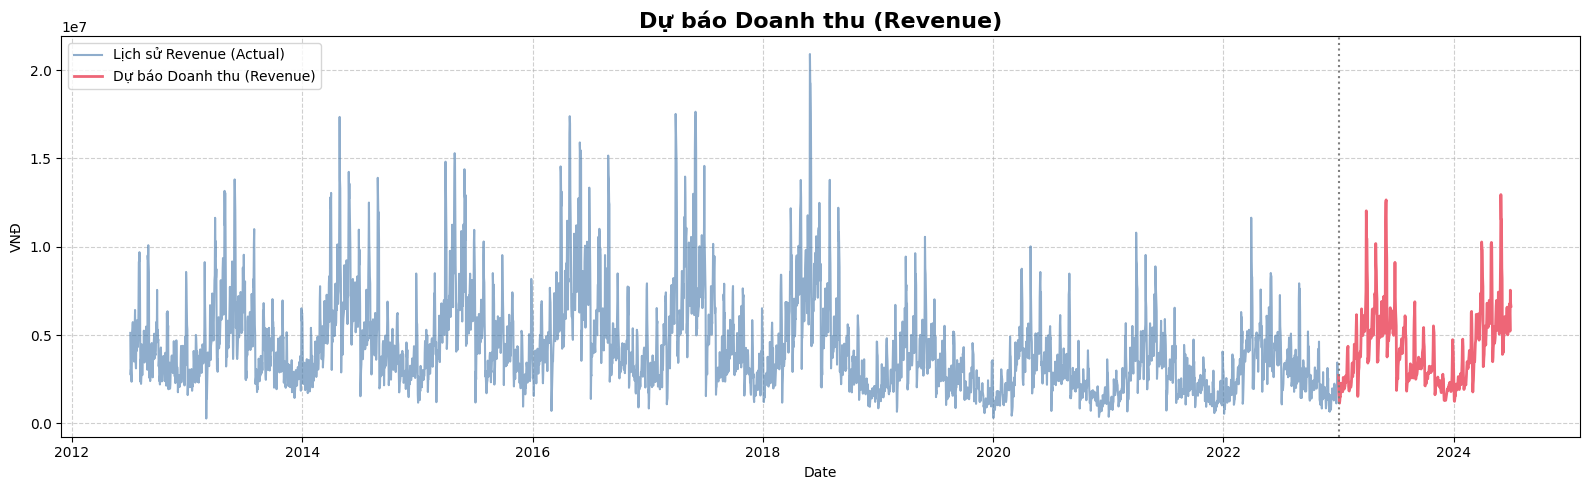

In [27]:
plot_results(feat, forecast_dates, sub[['Revenue']])

Code kiểm tra và lưu tham số tối ưu mà Optuna tìm được

In [28]:
print("BEST PARAMS FOR REVENUE:")
print(best_params_rev)

print("BEST PARAMS FOR COGS:")
print(best_params_cog)

BEST PARAMS FOR REVENUE:
{'alpha': 4.651206740228129, 'learning_rate': 0.012649306946952866, 'num_leaves': 106, 'min_data_in_leaf': 20, 'feature_fraction': 0.8929877808289013, 'bagging_fraction': 0.5619370678959162, 'bagging_freq': 5, 'lambda_l1': 0.007752054307376534, 'lambda_l2': 0.0018092487996633718, 'objective': 'huber', 'metric': 'mae', 'verbosity': -1, 'seed': 42, 'deterministic': True}
BEST PARAMS FOR COGS:
{'alpha': 2.3009412440319457, 'learning_rate': 0.021875064185293114, 'num_leaves': 38, 'min_data_in_leaf': 69, 'feature_fraction': 0.6299847555842242, 'bagging_fraction': 0.9004638887993759, 'bagging_freq': 4, 'lambda_l1': 5.8681118009797636e-08, 'lambda_l2': 2.682568431688553e-08, 'objective': 'huber', 'metric': 'mae', 'verbosity': -1, 'seed': 42, 'deterministic': True}


In [29]:
# best_configs = {
#     "revenue": best_params_rev,
#     "cogs": best_params_cog
# }

# # Xuất ra file json
# with open('../output/params/optuna_LGBM_params.json', 'w') as f:
#     json.dump(best_configs, f, indent=4)

# print("Đã lưu tham số vào file 'optuna_LGBM_params.json'")

### Feature Importance

FEATURE IMPORTANCE - REVENUE (LIGHTGBM BASE)
Đã lưu biểu đồ tại: ../output/figures/Top_20_Features___Revenue.png


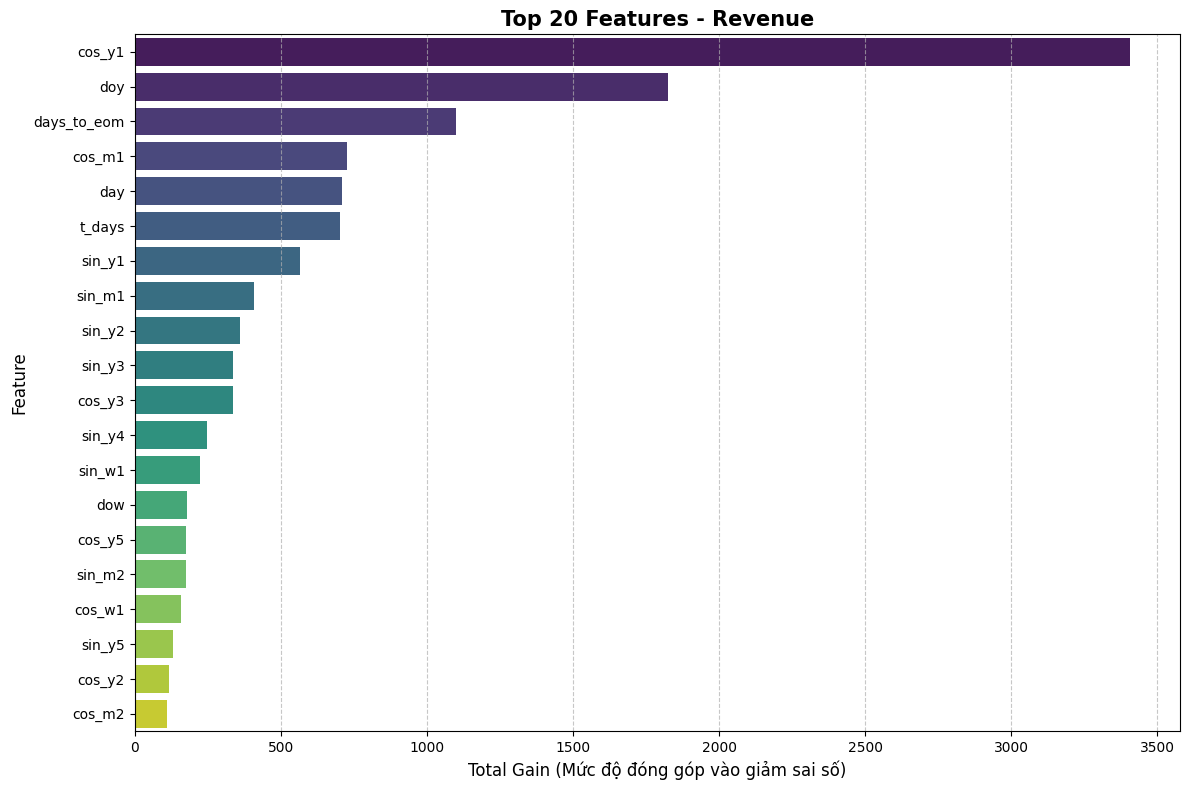

,Feature,Gain,Gain_Percentage
22,cos_y1,3407.274954,28.369341
4,doy,1825.342497,15.197999
7,days_to_eom,1099.235473,9.152354
36,cos_m1,728.363921,6.064437
2,day,709.784474,5.909742
16,t_days,702.876123,5.852223
21,sin_y1,566.992756,4.720843
35,sin_m1,409.350151,3.408294
23,sin_y2,359.253934,2.991187
25,sin_y3,338.291738,2.816654



FEATURE IMPORTANCE - COGS (LIGHTGBM BASE)
Đã lưu biểu đồ tại: ../output/figures/Top_20_Features___COGS.png


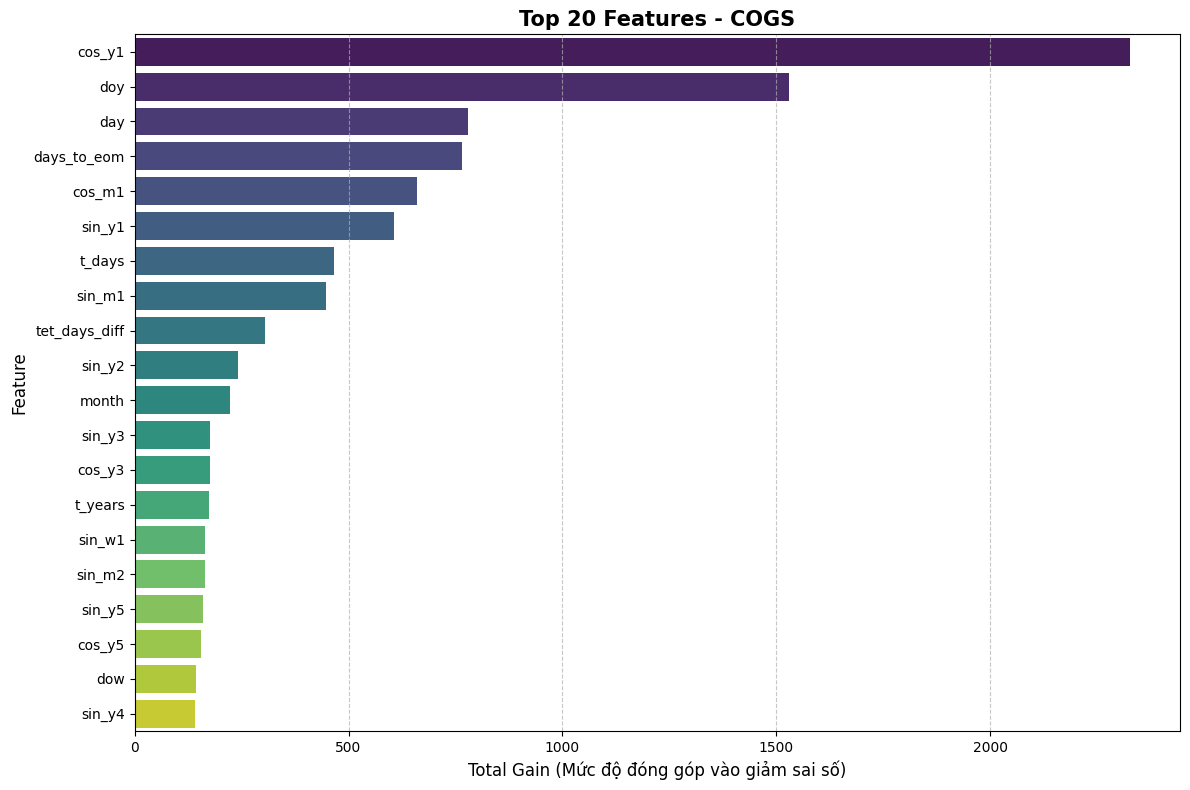

,Feature,Gain,Gain_Percentage
22,cos_y1,2327.605319,23.736026
4,doy,1530.271099,15.605118
2,day,779.602865,7.950091
7,days_to_eom,765.047855,7.801665
36,cos_m1,660.832526,6.738917
21,sin_y1,605.185193,6.171447
16,t_days,466.167100,4.753793
35,sin_m1,446.924947,4.557569
49,tet_days_diff,305.370561,3.114052
23,sin_y2,242.075765,2.468596


In [30]:
def plot_lgb_feature_importance(model, feature_names, title, top_n=20):
    # Lấy mức độ quan trọng dựa trên 'gain' (tổng mức giảm sai số khi split bằng feature này)
    importance_gain = model.feature_importance(importance_type='gain')
    
    # Lấy mức độ quan trọng dựa trên 'split' (số lần feature này được dùng để chia nhánh)
    importance_split = model.feature_importance(importance_type='split')
    
    # Tạo DataFrame
    df_imp = pd.DataFrame({
        'Feature': feature_names,
        'Gain': importance_gain,
        'Split': importance_split
    })
    
    # Sắp xếp giảm dần theo Gain
    df_imp = df_imp.sort_values(by='Gain', ascending=False).head(top_n)
    
    # Chuẩn hóa cột Gain về % để dễ nhìn hơn (tùy chọn)
    df_imp['Gain_Percentage'] = (df_imp['Gain'] / df_imp['Gain'].sum()) * 100
    
    # Vẽ biểu đồ
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Gain', y='Feature', data=df_imp, palette='viridis')
    plt.title(title, fontsize=15, fontweight='bold')
    plt.xlabel('Total Gain (Mức độ đóng góp vào giảm sai số)', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    # Lưu biểu đồ
    save_path = f"../output/figures/{title.replace(' ', '_').replace('-', '_')}.png"
    plt.savefig(save_path, dpi=300)
    print(f"Đã lưu biểu đồ tại: {save_path}")
    
    plt.show()
    return df_imp

# Danh sách tên cột đã được định nghĩa ở bước Load Data (biến 'cols')
feature_names = cols

# 1. Trích xuất cho mô hình Revenue
print("="*60)
print("FEATURE IMPORTANCE - REVENUE (LIGHTGBM BASE)")
print("="*60)
rev_imp_df = plot_lgb_feature_importance(
    bf_rev, 
    feature_names, 
    "Top 20 Features - Revenue"
)
display(rev_imp_df[['Feature', 'Gain', 'Gain_Percentage']].head(10))

# 2. Trích xuất cho mô hình COGS
print("\n" + "="*60)
print("FEATURE IMPORTANCE - COGS (LIGHTGBM BASE)")
print("="*60)
cog_imp_df = plot_lgb_feature_importance(
    bf_cog, 
    feature_names, 
    "Top 20 Features - COGS"
)
display(cog_imp_df[['Feature', 'Gain', 'Gain_Percentage']].head(10))

### SHAP

Phân tích SHAP (LightGBM Revenue)

Đang tính toán giá trị SHAP cho LightGBM (Revenue)...
Đã lưu biểu đồ SHAP Summary tại: ..\output\figures\shap_summary_lgb_rev.png


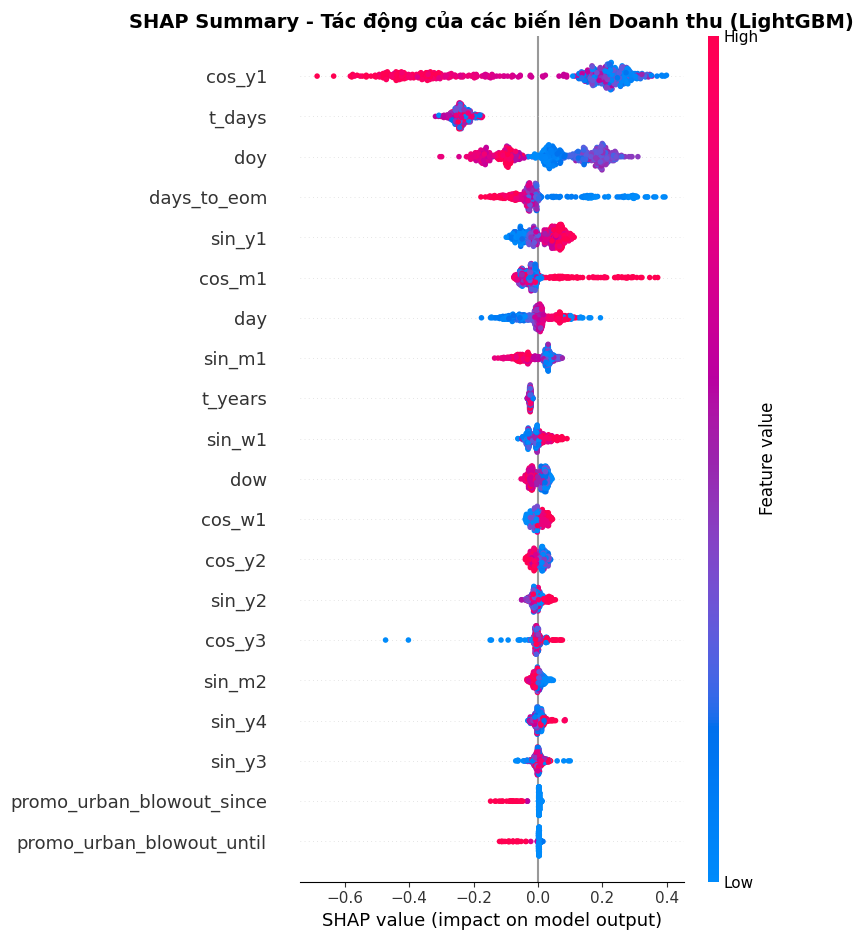

Đã lưu biểu đồ SHAP Bar tại: ..\output\figures\shap_bar_lgb_rev.png


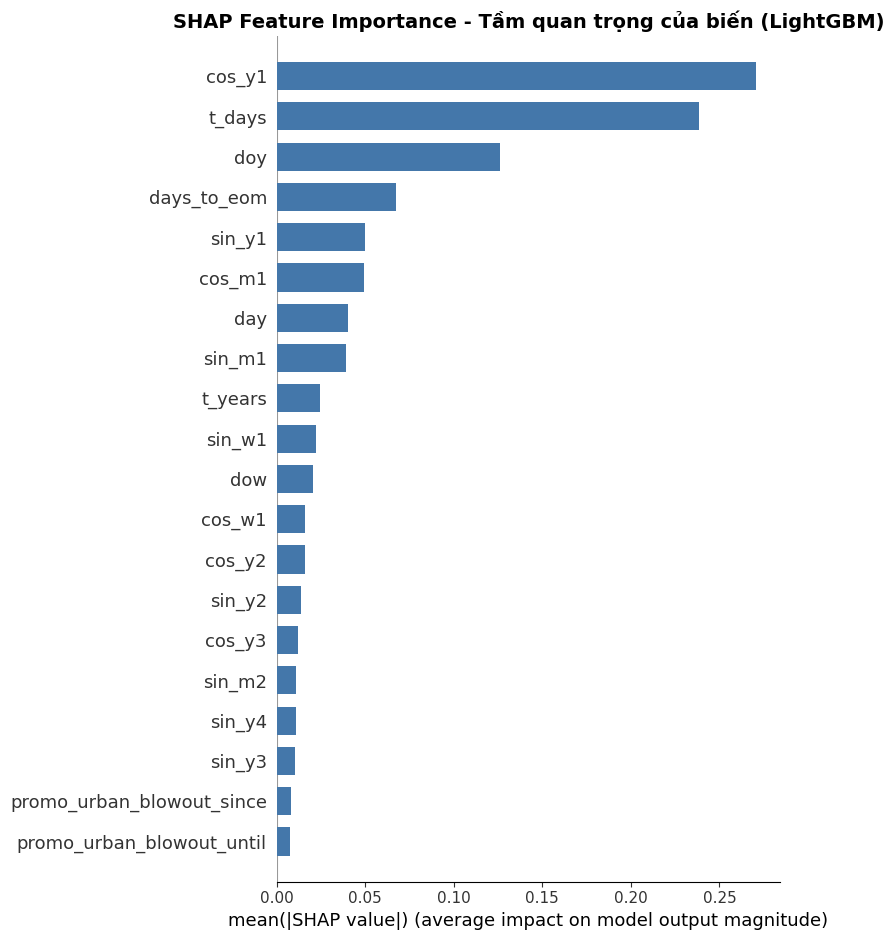

In [31]:

print("Phân tích SHAP (LightGBM Revenue)\n")


# Chuyển đổi dữ liệu Test sang DataFrame để biểu đồ tự động nhận diện tên biến
X_te_df = pd.DataFrame(X_te, columns=cols)

# Khởi tạo TreeExplainer cho mô hình LightGBM Revenue (bf_rev)
# TreeExplainer được tối ưu hóa riêng cho các mô hình dạng cây, tốc độ tính toán cực nhanh
print("Đang tính toán giá trị SHAP cho LightGBM (Revenue)...")
explainer_lgb = shap.TreeExplainer(bf_rev)

# Tính toán ma trận SHAP values
shap_values_lgb = explainer_lgb.shap_values(X_te_df)


# BIỂU ĐỒ 1: SHAP Summary Plot (Mật độ và Tác động)
# Ý nghĩa: Xem biến nào làm TĂNG dự báo (điểm đỏ bên phải) và GIẢM dự báo
plt.figure(figsize=(12, 8))
plt.title("SHAP Summary - Tác động của các biến lên Doanh thu (LightGBM)", fontsize=14, fontweight='bold')

# Dùng show=False để Matplotlib không xóa bộ nhớ đệm trước khi lưu ảnh
shap.summary_plot(shap_values_lgb, X_te_df, show=False)

plt.tight_layout()
save_path_summary = OUT_DIR / 'figures' / 'shap_summary_lgb_rev.png'
plt.savefig(save_path_summary, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Đã lưu biểu đồ SHAP Summary tại: {save_path_summary}")
plt.show()


# BIỂU ĐỒ 2: SHAP Bar Plot (Feature Importance theo lý thuyết Shapley)
# Ý nghĩa: Đánh giá tầm quan trọng tổng thể của biến, có thể dùng thay thế biểu đồ Gain
plt.figure(figsize=(12, 8))
plt.title("SHAP Feature Importance - Tầm quan trọng của biến (LightGBM)", fontsize=14, fontweight='bold')

# plot_type="bar" sẽ tính trung bình trị tuyệt đối của SHAP value cho mỗi biến
shap.summary_plot(shap_values_lgb, X_te_df, plot_type="bar", show=False, color="#4477AA")

plt.tight_layout()
save_path_bar = OUT_DIR / 'figures' / 'shap_bar_lgb_rev.png'
plt.savefig(save_path_bar, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Đã lưu biểu đồ SHAP Bar tại: {save_path_bar}")
plt.show()